In [41]:
%matplotlib widget
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.signal import savgol_filter, medfilt

In [42]:
normal_limb_path = r'/home/erie/Tonometry/data_process/pressure_limb_data/juan_data/juan_normal.csv' 
pressure_limb_path = r'/home/erie/Tonometry/data_process/pressure_limb_data/juan_data/juan_pressure.csv'

In [43]:
def lvdt_csv_read(file_path):
    data = pd.read_csv(file_path, skiprows=1, header=None)
    time = data.iloc[:, 0].to_numpy()
    lvdt_voltage = data.iloc[:, 1].to_numpy()
    lvdt_disp = data.iloc[:, 2].to_numpy()
    motor_state = data.iloc[:, 3]

    t_max = time.max()
    mask = (time >= t_max - 26) & (time <= t_max)
    time = time[mask]
    time = time - time[0]  # Reset time to start from zero

    lvdt_disp = lvdt_disp[mask]
    lvdt_disp = medfilt(lvdt_disp, kernel_size=7)
    lvdt_disp = lvdt_disp - lvdt_disp[0]
    return np.vstack((time, lvdt_disp)).T


In [44]:
nomarl_limb_data = lvdt_csv_read(normal_limb_path)
pressure_limb_data = lvdt_csv_read(pressure_limb_path)

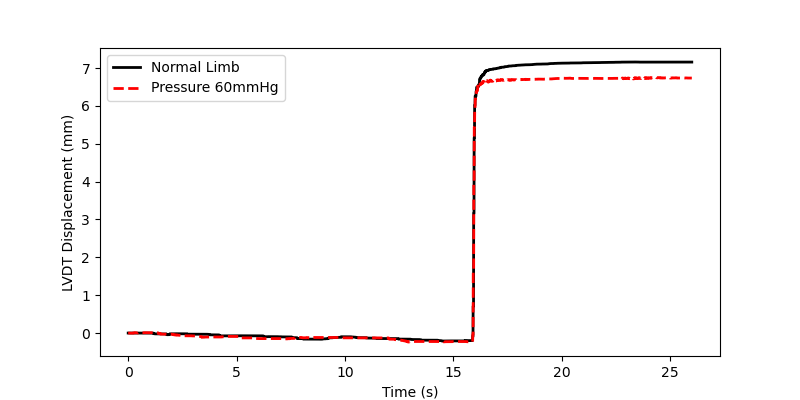

In [45]:
plt.figure(figsize=(8, 4))
lw = 2
plt.plot(nomarl_limb_data[:,0], nomarl_limb_data[:,1], color = 'black', linewidth = lw, label = 'Normal Limb')
plt.plot(pressure_limb_data[:,0], pressure_limb_data[:,1], color = 'red', linestyle = "--", linewidth = lw, label = 'Pressure 60mmHg')
# plt.ylim(-16,2)
plt.xlabel('Time (s)')
plt.ylabel('LVDT Displacement (mm)')
plt.legend()
# plt.savefig(f"Normal_vs_pressured_limb_long_indent.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()